TASK 1 - load dataset_EDA

import libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

1.Load the dataset 

In [9]:
df = pd.read_csv('C:\\Users\\fcdhs\\AppData\\Local\\Temp\\9a077ddf-a88d-4c48-990a-a9a95c4b758c_archive.zip.58c\\india_housing_prices.csv')
df.head()         # display first 5 rows of the DataFrame

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [10]:
df.shape         # display the shape of the DataFrame (rows, columns)

(250000, 23)

In [11]:
df.dtypes        # data types of each column

ID                                  int64
State                                 str
City                                  str
Locality                              str
Property_Type                         str
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                      str
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility        str
Parking_Space                         str
Security                              str
Amenities                             str
Facing                                str
Owner_Type                            str
Availability_Status                   str
dtype: object

2.null value analysis

In [12]:
df.isnull().sum()  # check for missing values in each column    

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [13]:
(df.isnull().sum() / df.shape[0]) * 100  # percentage of missing values in each column

ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64

In [14]:
null_report = pd.DataFrame({'column_name': df.columns, 'missing_values': df.isnull().sum(), 'missing_percentage': (df.isnull().sum() / df.shape[0]) * 100})
print(null_report)  # display the null report DataFrame

                                                   column_name  \
ID                                                          ID   
State                                                    State   
City                                                      City   
Locality                                              Locality   
Property_Type                                    Property_Type   
BHK                                                        BHK   
Size_in_SqFt                                      Size_in_SqFt   
Price_in_Lakhs                                  Price_in_Lakhs   
Price_per_SqFt                                  Price_per_SqFt   
Year_Built                                          Year_Built   
Furnished_Status                              Furnished_Status   
Floor_No                                              Floor_No   
Total_Floors                                      Total_Floors   
Age_of_Property                                Age_of_Property   
Nearby_Sch

no null value found in dataframe, there is no need to fill null values

3.Duplicate detection and removal

In [15]:
df.duplicated().sum()  # check for duplicate rows in the DataFrame

np.int64(0)

In [16]:
df.drop_duplicates(inplace=True)  # drop duplicate rows from the DataFrame

4.Data type correction

In [17]:
memory_before = df.memory_usage(deep=True).sum()  # memory usage in MB before optimization

In [18]:
df["ID"] = df["ID"].astype("str")  # convert 'id' column to string type

In [19]:
print(df.columns.tolist())  # print all column names

['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [20]:
for col in ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']:
    df[col] = df[col].astype("category")  # convert categorical columns to 'category' type

In [21]:
memory_after = df.memory_usage(deep=True).sum()  # memory usage in MB after optimization

In [22]:
print("Memory usage before optimization: {:.2f} MB".format(memory_before / (1024 ** 2)))
print("Memory usage after optimization: {:.2f} MB".format(memory_after / (1024 ** 2)))

Memory usage before optimization: 187.03 MB
Memory usage after optimization: 35.48 MB


5.Descriptive statistics and skewness

In [23]:
df["Price_per_SqFt"] = df["Price_in_Lakhs"]/df["Size_in_SqFt"]  # create a new column 'Price_per_SqFt' by dividing 'Price_per_Lakhs' by 'Size_in_sqft'

In [24]:
df.head(2)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.103325,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.082707,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


In [25]:
df.describe()

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,2.999396,2749.813216,254.586854,0.130583,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,1.415521,1300.606954,141.349921,0.130719,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,500.000000,10.000000,0.002022,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,2.000000,1623.000000,132.550000,0.048028,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,3.000000,2747.000000,253.870000,0.092447,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,4.000000,3874.000000,376.880000,0.159874,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,5.000000,5000.000000,500.000000,0.991820,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [26]:
print("skewness of numerical columns:")
df[['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']].skew()

skewness of numerical columns:


BHK                 0.000543
Size_in_SqFt        0.000796
Price_in_Lakhs      0.008206
Price_per_SqFt      2.320225
Year_Built         -0.000167
Floor_No            0.005311
Total_Floors       -0.000666
Age_of_Property     0.000167
Nearby_Schools     -0.001258
Nearby_Hospitals    0.001099
dtype: float64

Price_per_SqFt had skew = 2.319 (strongly positive) —
everything else was under 0.01 (essentially symmetric). This single number
predicted exactly the shape we will see in the histogram later.

6.Outlier detection with IQR

In [27]:
Q1 = df['Price_in_Lakhs'].quantile(0.25)
Q3 = df['Price_in_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
outliers_in_Price_in_Lakhs = df[(df['Price_in_Lakhs'] < Q1 - 1.5*IQR) | (df['Price_in_Lakhs'] > Q3 + 1.5*IQR)]

In [28]:
print("outliers_in_Price_in_Lakhs: ", outliers_in_Price_in_Lakhs.shape[0])  # display the number of outliers in the 'Price_in_Lakhs' column

outliers_in_Price_in_Lakhs:  0


In [29]:
Q1 = df['Price_per_SqFt'].quantile(0.25)
Q3 = df['Price_per_SqFt'].quantile(0.75)
IQR = Q3 - Q1
outliers_in_Price_per_SqFt = df[(df['Price_per_SqFt'] < Q1 - 1.5*IQR) | (df['Price_per_SqFt'] > Q3 + 1.5*IQR)]

In [30]:
print("outliers_in_Price_per_SqFt: ", outliers_in_Price_per_SqFt.shape[0])  # display the number of outliers in the 'Price_per_SqFt' column

outliers_in_Price_per_SqFt:  19723


outliers in each columns

In [31]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    outlier_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    }

# Convert to DataFrame for readability
report_df = pd.DataFrame(outlier_report).T
print(report_df)

                           Q1           Q3          IQR  Lower Bound  \
BHK                  2.000000     4.000000     2.000000     -1.00000   
Size_in_SqFt      1623.000000  3874.000000  2251.000000  -1753.50000   
Price_in_Lakhs     132.550000   376.880000   244.330000   -233.94500   
Price_per_SqFt       0.048028     0.159874     0.111845     -0.11974   
Year_Built        1998.000000  2015.000000    17.000000   1972.50000   
Floor_No             7.000000    23.000000    16.000000    -17.00000   
Total_Floors         8.000000    23.000000    15.000000    -14.50000   
Age_of_Property     10.000000    27.000000    17.000000    -15.50000   
Nearby_Schools       3.000000     8.000000     5.000000     -4.50000   
Nearby_Hospitals     3.000000     8.000000     5.000000     -4.50000   

                  Upper Bound  Outlier Count  
BHK                  7.000000            0.0  
Size_in_SqFt      7250.500000            0.0  
Price_in_Lakhs     743.375000            0.0  
Price_per_SqFt     

i only found outliers in price_per_sqft.

7.Visualizations 

A line plot

In [32]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns[:10]

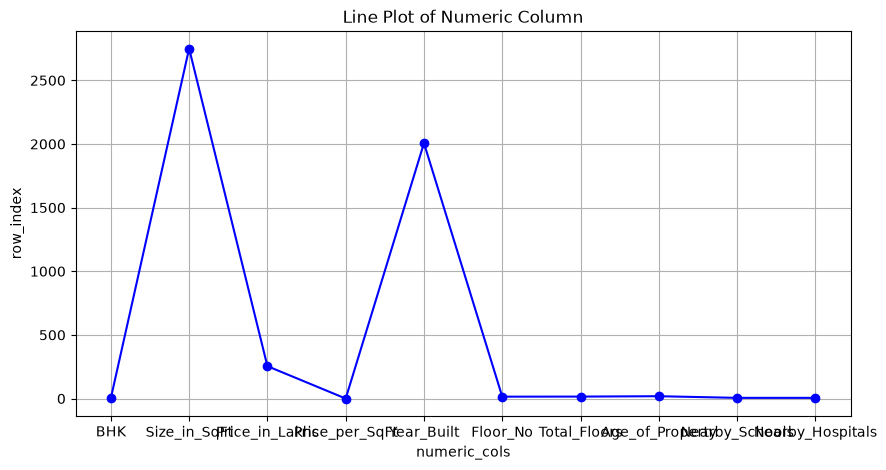

In [33]:
# line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(numeric_cols, df[numeric_cols].mean(), marker='o', linestyle='-', color='b')

plt.title("Line Plot of Numeric Column")
plt.xlabel("numeric_cols")
plt.ylabel("row_index")

plt.grid(True)
plt.show()

A bar chart

Text(0.5, 1.0, 'Mean Price (Lakhs) by Property Type')

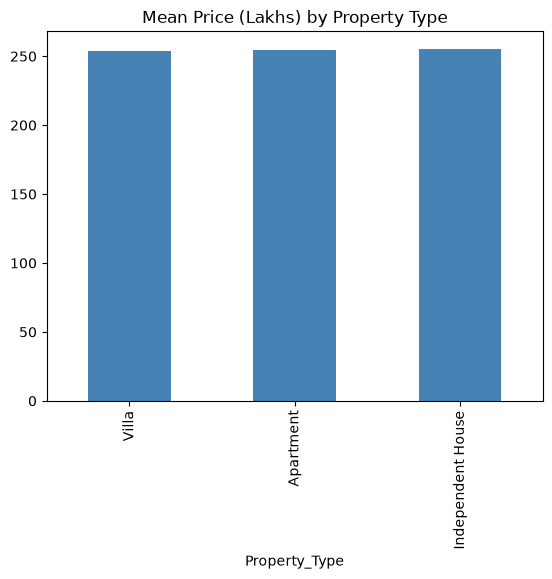

In [34]:
# bar plot
grp = df.groupby("Property_Type")["Price_in_Lakhs"].mean().sort_values()
grp.plot.bar(color="steelblue")
plt.title("Mean Price (Lakhs) by Property Type")

A histogram

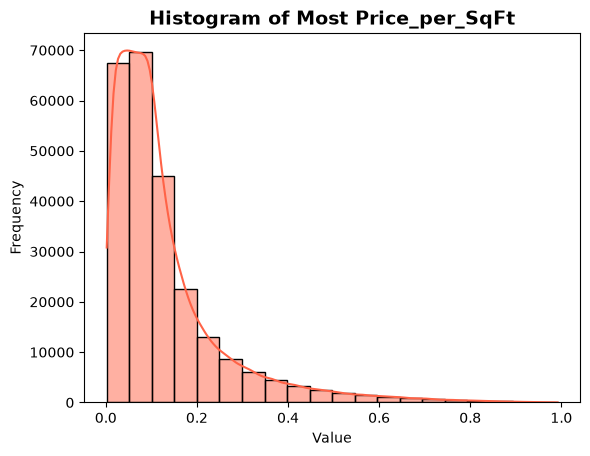

In [35]:
sns.histplot(df['Price_per_SqFt'], bins=20, kde=True, color="tomato")

plt.title("Histogram of Most Price_per_SqFt", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

A scatter plot

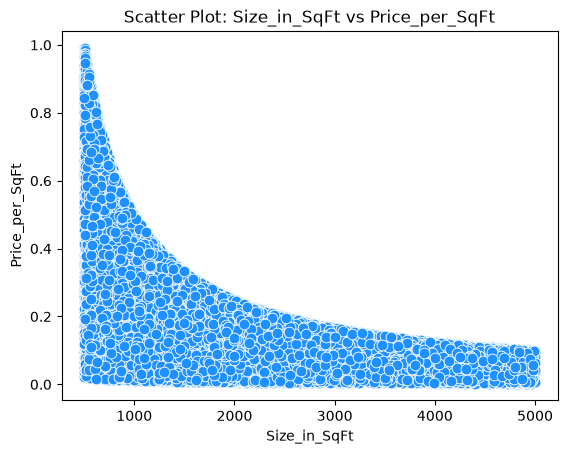

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: numeric columns = 'income' and 'spending'
sns.scatterplot(x=df['Size_in_SqFt'], y=df['Price_per_SqFt'], color="dodgerblue", s=60)

plt.title("Scatter Plot: Size_in_SqFt vs Price_per_SqFt")
plt.xlabel("Size_in_SqFt")
plt.ylabel("Price_per_SqFt")
plt.show()

A box plot

C:\Users\fcdhs\AppData\Local\Temp\ipykernel_18244\1278195896.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['State'], y=df['City'], palette="Set2",)


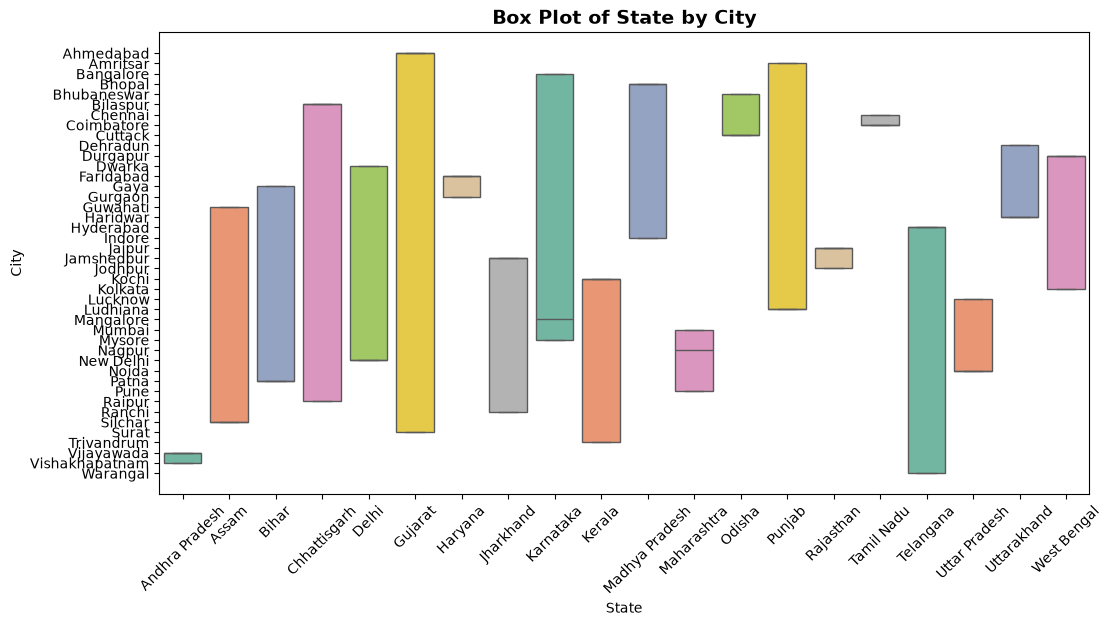

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Example: numeric column = 'sales', categorical column = 'region'
sns.boxplot(x=df['State'], y=df['City'], palette="Set2",)

plt.title("Box Plot of State by City", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("City")
plt.xticks(rotation=45)
plt.show()

8.Correlation heat map

In [38]:
df.corr(numeric_only=True)

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
BHK,1.000000,-0.001033,-0.000980,0.001138,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.001033,1.000000,-0.002529,-0.614610,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price_in_Lakhs,-0.000980,-0.002529,1.000000,0.555781,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,0.001138,-0.614610,0.555781,1.000000,-0.001330,-0.001904,0.004161,0.001330,-0.000058,-0.000122
Year_Built,0.000917,0.004135,0.002714,-0.001330,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,0.001263,-0.002775,-0.001719,-0.001904,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,-0.002862,-0.003451,0.001283,0.004161,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.000917,-0.004135,-0.002714,0.001330,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.000762,0.001966,0.000155,-0.000058,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246
Nearby_Hospitals,0.001162,-0.001695,-0.002769,-0.000122,-0.002719,0.001428,-0.005867,0.002719,-0.002246,1.000000


<Axes: >

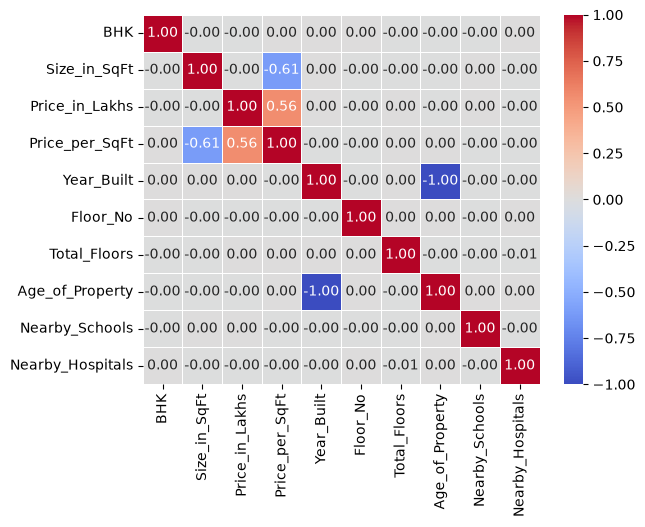

In [39]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

9a. Imputation strategy comparison

In [40]:
# Step 1: Identify skewness for numeric columns
from scipy.stats import skew
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Step 2: Pick top 2 columns with highest absolute skewness
top2_cols = skew_values.abs().sort_values(ascending=False).head(2).index
print("Top 2 skewed columns:", top2_cols.tolist())

# Step 3: Compute mean and median for each column (before imputation)
for col in top2_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_values[col]:.2f}")

# Step 4: Choose imputation strategy based on skewness direction
# Positively skewed → median; Negatively skewed → median (since mean is pulled away)
for col in top2_cols:
    chosen_val = df[col].median()
    df[col] = df[col].fillna(chosen_val)

# Step 5: Confirm no nulls remain
print("\nNull counts after imputation:\n", df[top2_cols].isnull().sum())

Top 2 skewed columns: ['Price_per_SqFt', 'Price_in_Lakhs']
Price_per_SqFt: mean=0.13, median=0.09, skew=2.32
Price_in_Lakhs: mean=254.59, median=253.87, skew=0.01

Null counts after imputation:
 Price_per_SqFt    0
Price_in_Lakhs    0
dtype: int64


9b. Spearman rank correlation

In [41]:
import pandas as pd

# Step 1: Pearson correlation (linear relationships)
pearson_corr = df.corr(method='pearson',	numeric_only=True)

# Step 2: Spearman correlation (rank-based monotonic relationships)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Step 3: Absolute difference matrix
diff_matrix = (spearman_corr - pearson_corr).abs()

# Step 4: Extract top 3 pairs with largest differences
pairs = []
cols = df.select_dtypes(include=['int64','float64']).columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], diff_matrix.loc[cols[i], cols[j]]))

top3 = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

# Step 5: Print results
print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

Pearson Correlation Matrix:
                        BHK  Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  \
BHK               1.000000     -0.001033       -0.000980        0.001138   
Size_in_SqFt     -0.001033      1.000000       -0.002529       -0.614610   
Price_in_Lakhs   -0.000980     -0.002529        1.000000        0.555781   
Price_per_SqFt    0.001138     -0.614610        0.555781        1.000000   
Year_Built        0.000917      0.004135        0.002714       -0.001330   
Floor_No          0.001263     -0.002775       -0.001719       -0.001904   
Total_Floors     -0.002862     -0.003451        0.001283        0.004161   
Age_of_Property  -0.000917     -0.004135       -0.002714        0.001330   
Nearby_Schools   -0.000762      0.001966        0.000155       -0.000058   
Nearby_Hospitals  0.001162     -0.001695       -0.002769       -0.000122   

                  Year_Built  Floor_No  Total_Floors  Age_of_Property  \
BHK                 0.000917  0.001263     -0.002862        -

9c. Grouped aggregation.

In [42]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','category']).columns

C:\Users\fcdhs\AppData\Local\Temp\ipykernel_18244\2713603252.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object','category']).columns


In [43]:
df.groupby(df["State"])["Price_in_Lakhs"].agg(['mean', 'std', 'count'])

,mean,std,count
State,,,
Andhra Pradesh,255.197870,141.727467,12462
Assam,252.779235,141.957324,12496
Bihar,254.919040,141.271510,12369
Chhattisgarh,252.676337,142.132552,12456
Delhi,252.529900,141.009557,12552
Gujarat,255.790061,141.920164,12578
Haryana,254.445784,140.881936,12314
Jharkhand,253.610145,142.227911,12480
Karnataka,257.408465,141.417520,12424


In [44]:
df.shape

(250000, 23)

10.Save the clean dataset

In [45]:
df.to_csv('cleaned_india_housing_prices.csv', index=False)